In [2]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [14]:
con = duckdb.connect("../data/ev_twin.duckdb")

df = con.execute("""
    SELECT
        session_start,
        session_stop,
        energy_kwh,
        duration_hrs,
        connector_type,
        charger_id,
        location_id,
        month,
        season,
        day,
        carbon_intensity_gco2_kwh,
        carbon_emissions_gco2
    FROM charging_sessions
    ORDER BY session_start
""").df()

df["hour"]       = df["session_start"].dt.hour
df["date"]       = df["session_start"].dt.date
df["year"]       = df["session_start"].dt.year
df["is_weekend"] = df["session_start"].dt.dayofweek >= 5

print(f"Sessions : {len(df)}")
print(f"Date range: {df['session_start'].min()} → {df['session_start'].max()}")
print(f"Chargers : {df['charger_id'].nunique()}")
print(f"\n{df.dtypes}")

Sessions : 29775
Date range: 2021-03-18 17:39:00 → 2024-07-01 15:20:00
Chargers : 6

session_start                datetime64[us]
session_stop                 datetime64[us]
energy_kwh                          float64
duration_hrs                        float64
connector_type                          str
charger_id                            int64
location_id                           int64
month                                 int32
season                                  str
day                                     str
carbon_intensity_gco2_kwh             int32
carbon_emissions_gco2               float64
hour                                  int32
date                                 object
year                                  int32
is_weekend                             bool
dtype: object


In [2]:
print("=== Energy (kWh) ===")
print(df["energy_kwh"].describe())

print("\n=== Duration (hrs) ===")
print(df["duration_hrs"].describe())

print("\n=== Connector mix ===")
print(df["connector_type"].value_counts())

print("\n=== Sessions per year ===")
print(df["year"].value_counts().sort_index())

print("\n=== Sessions per charger ===")
print(df["charger_id"].value_counts().sort_index())

=== Energy (kWh) ===
count    29775.000000
mean        30.440584
std         18.207384
min          5.000000
25%         14.907500
50%         27.404000
75%         42.911000
max        110.733000
Name: energy_kwh, dtype: float64

=== Duration (hrs) ===
count    29775.000000
mean         0.741497
std          0.486143
min          0.035833
25%          0.416667
50%          0.644167
75%          0.950000
max         12.570278
Name: duration_hrs, dtype: float64

=== Connector mix ===
connector_type
IEC_62196_T2_COMBO    24435
CHADEMO                4265
IEC_62196_T2           1075
Name: count, dtype: int64

=== Sessions per year ===
year
2021     4035
2022     8515
2023    11264
2024     5961
Name: count, dtype: int64

=== Sessions per charger ===
charger_id
5000194    3976
5000195    3517
5000196    3734
5000197    4221
5000198    6725
5000199    7602
Name: count, dtype: int64


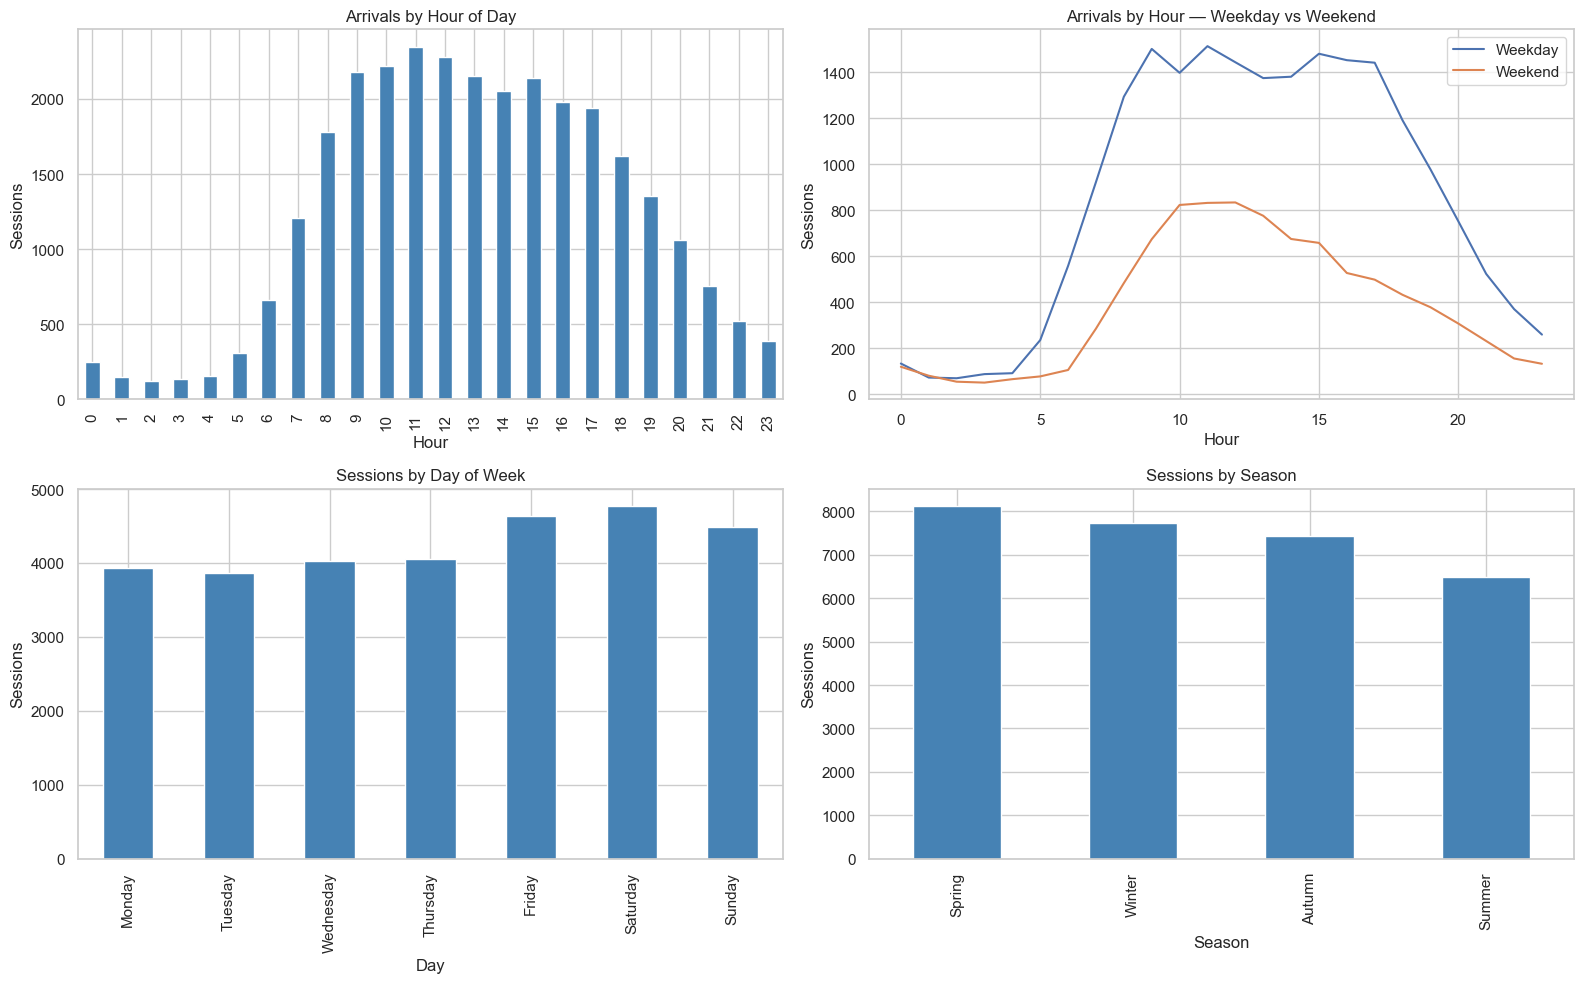

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly arrivals overall
df["hour"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0][0], color="steelblue"
)
axes[0][0].set_title("Arrivals by Hour of Day")
axes[0][0].set_xlabel("Hour")
axes[0][0].set_ylabel("Sessions")

# Weekday vs weekend
for label, group in df.groupby("is_weekend"):
    tag = "Weekend" if label else "Weekday"
    group["hour"].value_counts().sort_index().plot(
        kind="line", ax=axes[0][1], label=tag
    )
axes[0][1].set_title("Arrivals by Hour — Weekday vs Weekend")
axes[0][1].set_xlabel("Hour")
axes[0][1].set_ylabel("Sessions")
axes[0][1].legend()

# Sessions by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day"].value_counts().reindex(day_order).plot(
    kind="bar", ax=axes[1][0], color="steelblue"
)
axes[1][0].set_title("Sessions by Day of Week")
axes[1][0].set_xlabel("Day")
axes[1][0].set_ylabel("Sessions")

# Sessions by season
df["season"].value_counts().plot(
    kind="bar", ax=axes[1][1], color="steelblue"
)
axes[1][1].set_title("Sessions by Season")
axes[1][1].set_xlabel("Season")
axes[1][1].set_ylabel("Sessions")

plt.tight_layout()
plt.savefig("../notebooks/outputs/arrival_patterns.png", dpi=150)
plt.show()

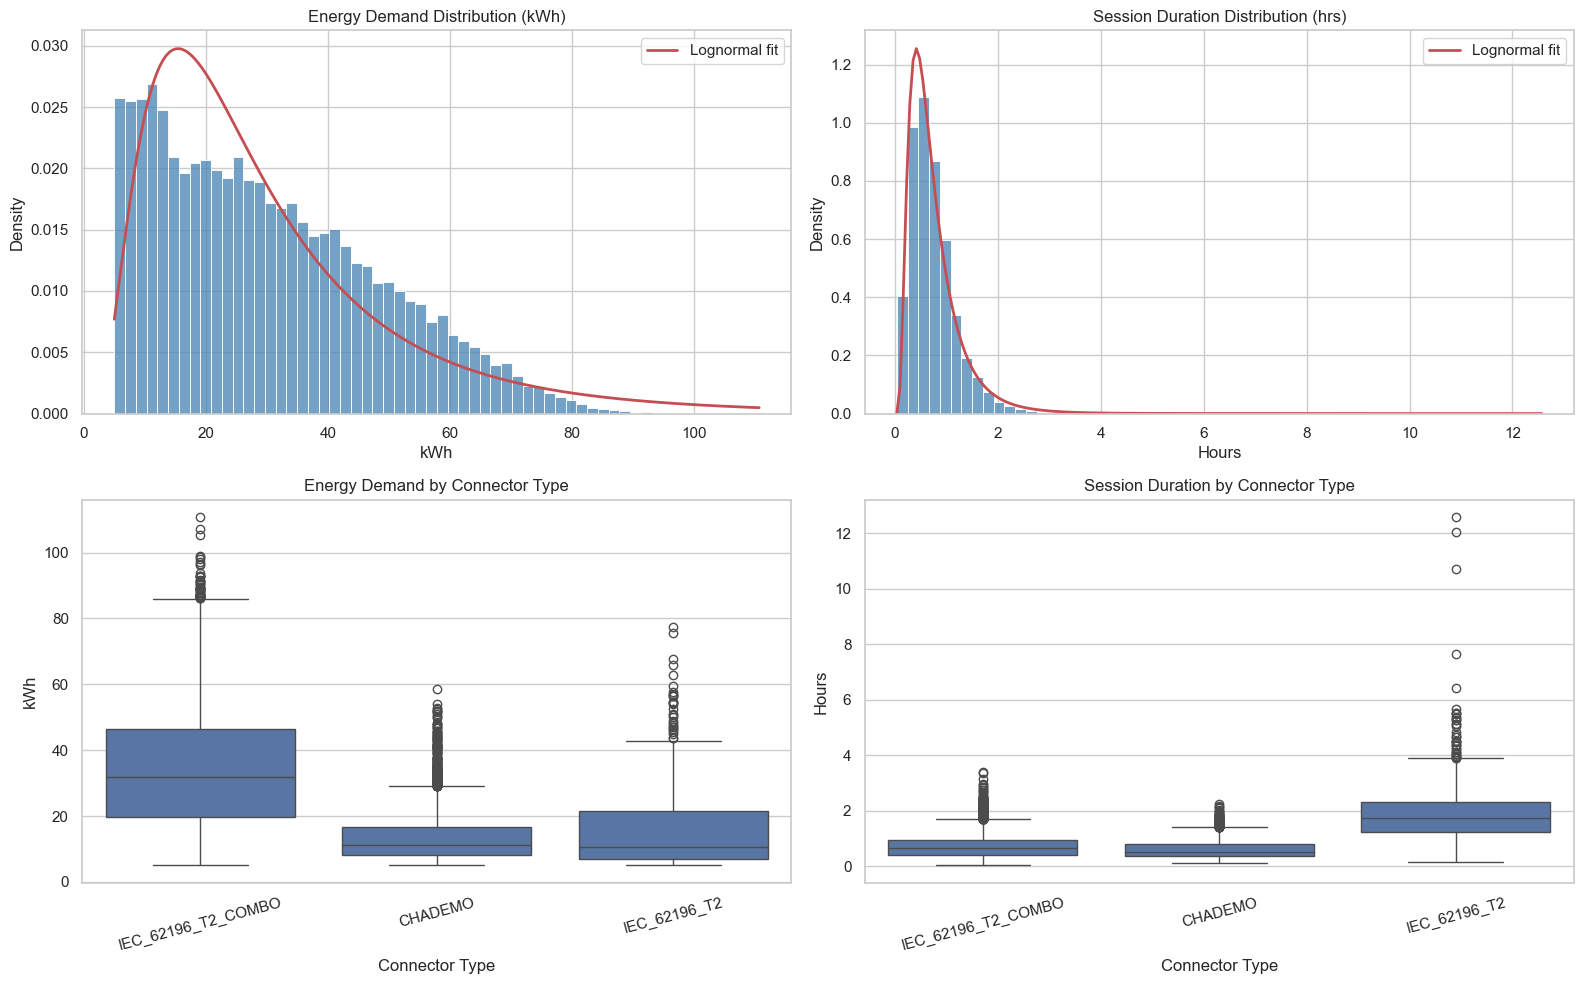

In [4]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Energy histogram + lognormal fit
ax = axes[0][0]
sns.histplot(df["energy_kwh"], bins=60, stat="density", ax=ax, color="steelblue")
params = stats.lognorm.fit(df["energy_kwh"].values, floc=0)
x = np.linspace(df["energy_kwh"].min(), df["energy_kwh"].max(), 200)
ax.plot(x, stats.lognorm.pdf(x, *params), "r-", lw=2, label="Lognormal fit")
ax.set_title("Energy Demand Distribution (kWh)")
ax.set_xlabel("kWh")
ax.legend()

# Duration histogram + lognormal fit
ax = axes[0][1]
sns.histplot(df["duration_hrs"], bins=60, stat="density", ax=ax, color="steelblue")
params_dur = stats.lognorm.fit(df["duration_hrs"].values, floc=0)
x = np.linspace(df["duration_hrs"].min(), df["duration_hrs"].max(), 200)
ax.plot(x, stats.lognorm.pdf(x, *params_dur), "r-", lw=2, label="Lognormal fit")
ax.set_title("Session Duration Distribution (hrs)")
ax.set_xlabel("Hours")
ax.legend()

# Energy by connector type
ax = axes[1][0]
sns.boxplot(data=df, x="connector_type", y="energy_kwh", ax=ax)
ax.set_title("Energy Demand by Connector Type")
ax.set_xlabel("Connector Type")
ax.set_ylabel("kWh")
ax.tick_params(axis="x", rotation=15)

# Duration by connector type
ax = axes[1][1]
sns.boxplot(data=df, x="connector_type", y="duration_hrs", ax=ax)
ax.set_title("Session Duration by Connector Type")
ax.set_xlabel("Connector Type")
ax.set_ylabel("Hours")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("../notebooks/outputs/energy_duration_distributions.png", dpi=150)
plt.show()

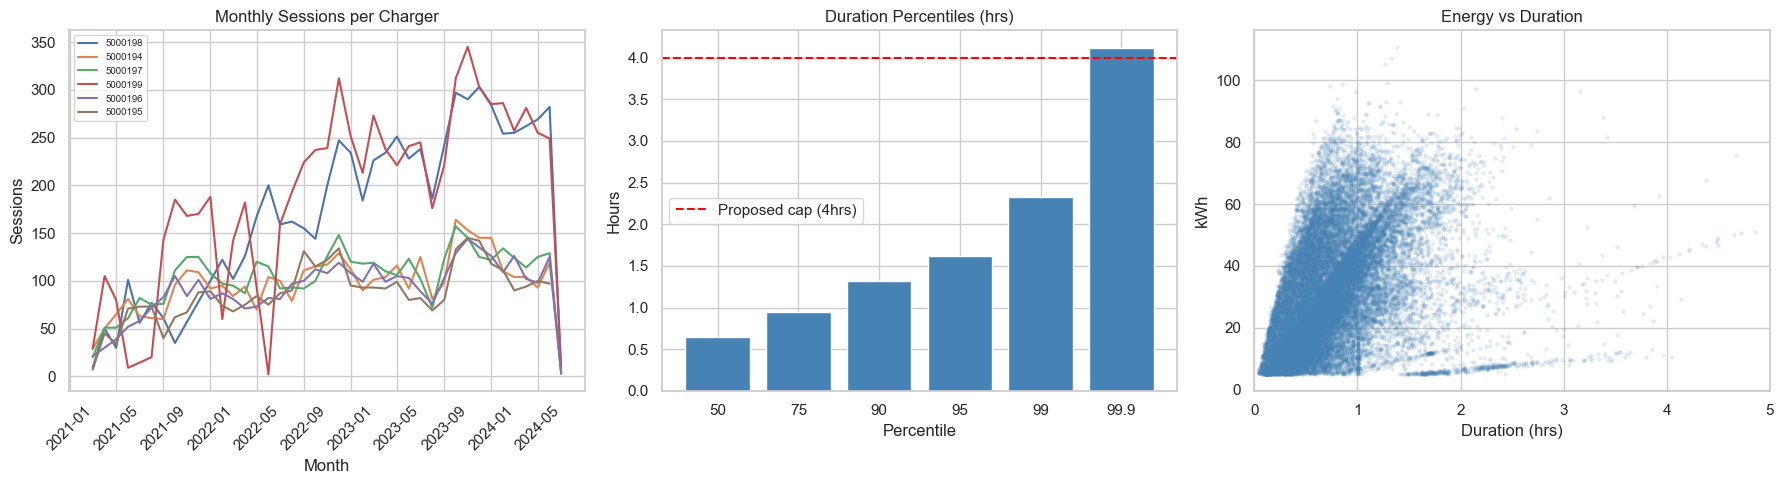

Duration percentiles:
  p50   : 0.64 hrs
  p75   : 0.95 hrs
  p90   : 1.32 hrs
  p95   : 1.62 hrs
  p99   : 2.32 hrs
  p99.9 : 4.12 hrs

Sessions > 4hrs : 33 (0.11%)
Sessions > 2hrs : 573 (1.92%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sessions per charger over time
sessions_by_month = df.groupby([
    df["session_start"].dt.to_period("M"), "charger_id"
])["energy_kwh"].count().reset_index()
sessions_by_month.columns = ["month", "charger_id", "sessions"]
sessions_by_month["month"] = sessions_by_month["month"].dt.to_timestamp()

ax = axes[0]
for charger in df["charger_id"].unique():
    subset = sessions_by_month[sessions_by_month["charger_id"] == charger]
    ax.plot(subset["month"], subset["sessions"], label=str(charger))
ax.set_title("Monthly Sessions per Charger")
ax.set_xlabel("Month")
ax.set_ylabel("Sessions")
ax.legend(fontsize=7)
ax.tick_params(axis="x", rotation=45)

# Duration outliers — cap check
ax = axes[1]
percentiles = [50, 75, 90, 95, 99, 99.9]
values = [df["duration_hrs"].quantile(p/100) for p in percentiles]
ax.bar([str(p) for p in percentiles], values, color="steelblue")
ax.set_title("Duration Percentiles (hrs)")
ax.set_xlabel("Percentile")
ax.set_ylabel("Hours")
ax.axhline(y=4, color="red", linestyle="--", label="Proposed cap (4hrs)")
ax.legend()

# Energy vs duration scatter
ax = axes[2]
ax.scatter(df["duration_hrs"], df["energy_kwh"], alpha=0.1, s=5, color="steelblue")
ax.set_title("Energy vs Duration")
ax.set_xlabel("Duration (hrs)")
ax.set_ylabel("kWh")
ax.set_xlim(0, 5)

plt.tight_layout()
plt.savefig("../notebooks/outputs/charger_utilisation.png", dpi=150)
plt.show()

# Print exact percentiles
print("Duration percentiles:")
for p, v in zip(percentiles, values):
    print(f"  p{p:<5}: {v:.2f} hrs")

print(f"\nSessions > 4hrs : {(df['duration_hrs'] > 4).sum()} ({(df['duration_hrs'] > 4).mean():.2%})")
print(f"Sessions > 2hrs : {(df['duration_hrs'] > 2).sum()} ({(df['duration_hrs'] > 2).mean():.2%})")

In [6]:
from scipy import stats

# ── Per connector type distributions ─────────────────────────────────────────
sim_params = {}

for connector in df["connector_type"].unique():
    subset = df[df["connector_type"] == connector].copy()
    
    # Fit lognormal to duration (good fit confirmed)
    dur_params = stats.lognorm.fit(subset["duration_hrs"].clip(upper=4).values, floc=0)
    
    # Use empirical for energy (poor lognormal fit)
    energy_values = subset["energy_kwh"].values
    
    sim_params[connector] = {
        "n_sessions":       len(subset),
        "share":            len(subset) / len(df),
        "duration_lognorm": dur_params,   # (s, loc, scale)
        "energy_mean":      energy_values.mean(),
        "energy_std":       energy_values.std(),
        "energy_p5":        np.percentile(energy_values, 5),
        "energy_p95":       np.percentile(energy_values, 95),
        "energy_values":    energy_values,  # kept for empirical sampling
    }

# ── Arrival rate by hour ──────────────────────────────────────────────────────
total_days    = (df["session_start"].max() - df["session_start"].min()).days
arrival_by_hour = df["hour"].value_counts().sort_index() / total_days

# ── Weekday vs weekend split ──────────────────────────────────────────────────
weekday_ratio = float((~df["is_weekend"]).mean())

# ── Print summary ─────────────────────────────────────────────────────────────
print("=== Connector Parameters ===")
for connector, params in sim_params.items():
    print(f"\n{connector}")
    print(f"  Share          : {params['share']:.2%}")
    print(f"  Energy mean    : {params['energy_mean']:.2f} kWh")
    print(f"  Energy std     : {params['energy_std']:.2f} kWh")
    print(f"  Duration lognorm params: s={params['duration_lognorm'][0]:.3f}, scale={params['duration_lognorm'][2]:.3f}")

print(f"\n=== Arrival Rates (sessions/day) ===")
print(arrival_by_hour.round(3).to_string())

print(f"\n=== General ===")
print(f"Weekday ratio  : {weekday_ratio:.2%}")
print(f"Total days     : {total_days}")
print(f"Avg sessions/day: {len(df)/total_days:.2f}")
print(f"N chargers     : {df['charger_id'].nunique()}")

=== Connector Parameters ===

IEC_62196_T2_COMBO
  Share          : 82.07%
  Energy mean    : 34.02 kWh
  Energy std     : 17.76 kWh
  Duration lognorm params: s=0.615, scale=0.602

CHADEMO
  Share          : 14.32%
  Energy mean    : 13.72 kWh
  Energy std     : 7.93 kWh
  Duration lognorm params: s=0.526, scale=0.543

IEC_62196_T2
  Share          : 3.61%
  Energy mean    : 15.52 kWh
  Energy std     : 11.79 kWh
  Duration lognorm params: s=0.606, scale=1.574

=== Arrival Rates (sessions/day) ===
hour
0     0.210
1     0.127
2     0.102
3     0.114
4     0.130
5     0.260
6     0.552
7     1.007
8     1.481
9     1.813
10    1.851
11    1.955
12    1.898
13    1.792
14    1.713
15    1.782
16    1.650
17    1.617
18    1.352
19    1.130
20    0.882
21    0.628
22    0.438
23    0.326

=== General ===
Weekday ratio  : 68.93%
Total days     : 1200
Avg sessions/day: 24.81
N chargers     : 6


In [15]:
import json

# ── Package for storage ───────────────────────────────────────────────────────
params_to_save = {
    "connector_params": {
        k: {
            "share":            v["share"],
            "energy_mean":      v["energy_mean"],
            "energy_std":       v["energy_std"],
            "energy_p5":        v["energy_p5"],
            "energy_p95":       v["energy_p95"],
            "duration_lognorm": list(v["duration_lognorm"]),
            "energy_values":    v["energy_values"].tolist(),
        }
        for k, v in sim_params.items()
    },
    "arrival_by_hour":  arrival_by_hour.to_dict(),
    "weekday_ratio":    weekday_ratio,
    "avg_sessions_day": len(df) / total_days,
    "n_chargers":       int(df["charger_id"].nunique()),
    "charger_ids":      df["charger_id"].unique().tolist(),
    "sim_start_date":   str(df["session_start"].min().date()),
    "sim_end_date":     str(df["session_start"].max().date()),
}

# ── Save to DuckDB ────────────────────────────────────────────────────────────
# con = duckdb.connect("../data/ev_twin.duckdb")

con.execute("""
    CREATE TABLE IF NOT EXISTS simulation_params (
        key       VARCHAR PRIMARY KEY,
        value_json VARCHAR
    )
""")

for key, value in params_to_save.items():
    con.execute("""
        INSERT OR REPLACE INTO simulation_params (key, value_json)
        VALUES (?, ?)
    """, [key, json.dumps(value)])

con.close()

print("Simulation parameters saved to DuckDB:")
for key in params_to_save:
    print(f"  {key}")

Simulation parameters saved to DuckDB:
  connector_params
  arrival_by_hour
  weekday_ratio
  avg_sessions_day
  n_chargers
  charger_ids
  sim_start_date
  sim_end_date


In [8]:
con = duckdb.connect("../data/ev_twin.duckdb")

print(con.execute("SELECT COUNT(*) FROM metering_raw WHERE meter_id in ('USB_E_SwitchMA', 'USB_E_SwitchMB')").fetchone())
df = con.execute("""
    SELECT * FROM metering_raw
    WHERE meter_id in ('USB_E_SwitchMA', 'USB_E_SwitchMB')
    LIMIT 3
""").df()

print(df)

con.close()

(115392,)
         meter_id            datetime  value
0  USB_E_SwitchMA 2021-03-18 11:30:00   11.7
1  USB_E_SwitchMA 2021-03-18 22:00:00   11.7
2  USB_E_SwitchMA 2021-03-19 02:00:00   11.7
